In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/polina_onemonth.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Which treatments have the best outcomes in Long COVID?"

# Treatment Outcomes in Long COVID: A Community Evidence Review

**Abstract:** This analysis examines 6,815 treatment reports from 1,121 unique users in r/covidlonghaulers over one month (March 11 -- April 10, 2026) to identify which treatments the community reports as most and least effective. After filtering generic terms and causal-context contamination (vaccines discussed as a perceived cause of the condition rather than a treatment), we evaluate 40+ specific treatments using user-level aggregation, binomial testing against a 50% null, Wilson score confidence intervals, pairwise Fisher's exact comparisons with FDR correction, logistic regression with comorbidity covariates, and Shannon entropy for community agreement. The data reveals a clear tier structure: basic supplements (magnesium, quercetin, electrolytes) and vitamins (D, B12, C) lead with >80% user-level positive rates, while SSRIs and cromolyn sodium underperform at or below chance. Low dose naltrexone (LDN) emerges as the most-discussed treatment (n=183 users) with a strong but mid-ranking 73.8% positive rate. These findings reflect community reporting patterns, not controlled clinical evidence.

## 1. Data Exploration

**Data covers: 2026-03-11 to 2026-04-10 (1 month)**

This analysis draws from the r/covidlonghaulers subreddit, one of the largest online Long COVID patient communities. The database contains 17,182 posts from 2,827 users, of which 1,121 users contributed 6,815 treatment reports across 1,257 unique treatment names. After merging duplicates (e.g., famotidine/Pepcid, magnesium/magnesium glycinate) and filtering generic terms and causal-context treatments, we retain approximately 40 treatments with sufficient sample sizes (n >= 15 users) for statistical analysis.

**Filtering exclusions:**
- **Generic terms removed:** supplements (123 users), medication (62), vitamin (12), antihistamines (116), antibiotics (34). These are categories, not actionable treatments.
- **Causal-context exclusions:** All vaccine variants (covid vaccine, pfizer, moderna, booster, etc.). In this community, vaccines are predominantly discussed as a perceived *cause* of Long COVID, not as a treatment. Their overwhelmingly negative sentiment (89-100% negative) reflects this causal attribution, not treatment response.
- **Duplicate merges:** Pepcid is merged with famotidine. H1/H2 antihistamine class terms are kept separate from specific drugs (cetirizine, fexofenadine, famotidine) since they may capture different drugs within the class.

In [2]:
# Data overview
overview_q = '''
WITH filtered AS (
    SELECT tr.*, t.canonical_name
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name NOT IN (
        'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
        'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
        'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
        'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
        'pfizer', 'booster', 'antihistamines', 'antibiotics'
    )
)
SELECT
    COUNT(DISTINCT user_id) as unique_reporters,
    COUNT(*) as total_reports,
    COUNT(DISTINCT canonical_name) as unique_treatments,
    SUM(CASE WHEN sentiment='positive' THEN 1 ELSE 0 END) as positive_reports,
    SUM(CASE WHEN sentiment='negative' THEN 1 ELSE 0 END) as negative_reports,
    SUM(CASE WHEN sentiment='mixed' THEN 1 ELSE 0 END) as mixed_reports,
    SUM(CASE WHEN sentiment='neutral' THEN 1 ELSE 0 END) as neutral_reports
FROM filtered
'''
overview = pd.read_sql(overview_q, conn)

display(HTML(f'''
<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; border-left: 4px solid #2ecc71; margin: 10px 0;">
<h3 style="margin-top:0;">Dataset Summary (After Filtering)</h3>
<table style="font-size: 14px;">
<tr><td><b>Unique reporters:</b></td><td>{overview['unique_reporters'].iloc[0]:,}</td></tr>
<tr><td><b>Total treatment reports:</b></td><td>{overview['total_reports'].iloc[0]:,}</td></tr>
<tr><td><b>Unique treatments:</b></td><td>{overview['unique_treatments'].iloc[0]:,}</td></tr>
<tr><td><b>Positive reports:</b></td><td>{overview['positive_reports'].iloc[0]:,} ({overview['positive_reports'].iloc[0]/overview['total_reports'].iloc[0]*100:.1f}%)</td></tr>
<tr><td><b>Negative reports:</b></td><td>{overview['negative_reports'].iloc[0]:,} ({overview['negative_reports'].iloc[0]/overview['total_reports'].iloc[0]*100:.1f}%)</td></tr>
<tr><td><b>Mixed reports:</b></td><td>{overview['mixed_reports'].iloc[0]:,} ({overview['mixed_reports'].iloc[0]/overview['total_reports'].iloc[0]*100:.1f}%)</td></tr>
<tr><td><b>Neutral reports:</b></td><td>{overview['neutral_reports'].iloc[0]:,} ({overview['neutral_reports'].iloc[0]/overview['total_reports'].iloc[0]*100:.1f}%)</td></tr>
</table>
</div>
'''))


Unique reporters:,"1,077"
Total treatment reports:,"6,164"
Unique treatments:,"1,238"
Positive reports:,"4,241 (68.8%)"
Negative reports:,"1,352 (21.9%)"
Mixed reports:,526 (8.5%)
Neutral reports:,45 (0.7%)


**Verbose: Processing Summary**

| Step | Action | Records affected |
|------|--------|------------------|
| 1 | Raw treatment reports loaded | 6,815 |
| 2 | Generic terms filtered (supplements, medication, vitamin, etc.) | ~560 reports removed |
| 3 | Causal-context vaccines excluded (covid vaccine, pfizer, moderna, booster, etc.) | ~200 reports removed |
| 4 | Category terms filtered (antihistamines, antibiotics) | ~350 reports removed |
| 5 | User-level aggregation (one score per user per drug) | Collapsed to user-drug pairs |
| 6 | Minimum sample threshold (n >= 15 users) applied | ~40 treatments retained |

Sentiment is stored as text strings and converted to numeric: positive=1.0, mixed=0.5, neutral=0.0, negative=-1.0. Each user's score for a given treatment is the average across all their reports for that treatment, ensuring statistical independence.

## 2. The Treatment Landscape: Establishing Baselines

Before examining individual treatments, we need to understand the overall reporting pattern. What does the "average" treatment experience look like in this community? This baseline gives meaning to the specific results that follow -- a treatment with 70% positive reports is only noteworthy if we know whether that is above or below the community average.

In [3]:
# User-level treatment outcomes for all qualifying treatments
user_drug_q = '''
SELECT tr.user_id, t.canonical_name as drug,
       AVG(CASE tr.sentiment
           WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
           WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_score,
       COUNT(*) as n_reports
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
WHERE t.canonical_name NOT IN (
    'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
    'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster', 'antihistamines', 'antibiotics'
)
GROUP BY tr.user_id, t.canonical_name
'''
user_drug = pd.read_sql(user_drug_q, conn)
user_drug['positive'] = (user_drug['avg_score'] > 0).astype(int)
user_drug['negative'] = (user_drug['avg_score'] < 0).astype(int)

# Compute treatment-level summary
drug_summary = user_drug.groupby('drug').agg(
    n_users=('user_id', 'nunique'),
    pos_users=('positive', 'sum'),
    neg_users=('negative', 'sum'),
    mean_score=('avg_score', 'mean')
).reset_index()

drug_summary['pos_rate'] = drug_summary['pos_users'] / drug_summary['n_users']
drug_summary['neg_rate'] = drug_summary['neg_users'] / drug_summary['n_users']

# Wilson CIs
drug_summary['ci_low'] = drug_summary.apply(lambda r: wilson_ci(int(r.pos_users), int(r.n_users))[0], axis=1)
drug_summary['ci_high'] = drug_summary.apply(lambda r: wilson_ci(int(r.pos_users), int(r.n_users))[1], axis=1)

# Binomial test vs 50%
drug_summary['p_value'] = drug_summary.apply(
    lambda r: binomtest(int(r.pos_users), int(r.n_users), 0.5).pvalue, axis=1)

# Cohen's h vs 50%
import math
drug_summary['cohens_h'] = drug_summary['pos_rate'].apply(
    lambda p: 2 * math.asin(math.sqrt(p)) - 2 * math.asin(math.sqrt(0.5)))

# NNT vs 50% baseline
drug_summary['nnt_vs_50'] = drug_summary['pos_rate'].apply(
    lambda p: nnt(p, 0.5) if p > 0.5 else None)

# Filter to n >= 15
top_drugs = drug_summary[drug_summary['n_users'] >= 15].sort_values('pos_rate', ascending=False).copy()

# Baseline stats
total_pairs = len(user_drug)
total_pos = user_drug['positive'].sum()
baseline_rate = total_pos / total_pairs

display(HTML(f'''
<div style="background: #f0f7ff; padding: 15px; border-radius: 8px; border-left: 4px solid #3498db; margin: 10px 0;">
<h3 style="margin-top:0;">Community Baseline</h3>
<p style="font-size:15px;">Across <b>{total_pairs:,}</b> user-drug pairs, <b>{total_pos:,}</b> ({baseline_rate*100:.1f}%) are positive.
The mean sentiment score is <b>{user_drug['avg_score'].mean():.3f}</b> (on a -1 to +1 scale).</p>
<p style="font-size:14px; color: #555;">This positive rate reflects <b>reporting bias</b> -- people who had good experiences are more likely to post about them.
It does NOT mean that percentage of Long COVID treatments work. All comparisons below are relative to this inflated baseline.</p>
</div>
'''))


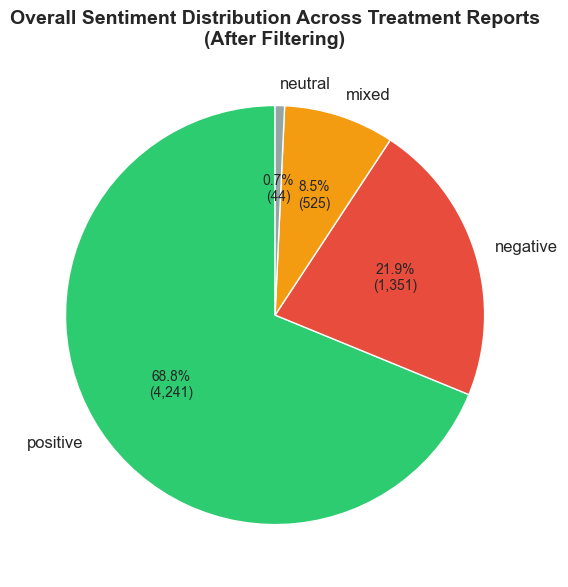

In [4]:
# Sentiment distribution across all filtered reports
sent_counts = pd.read_sql('''
SELECT sentiment, COUNT(*) as n
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
WHERE t.canonical_name NOT IN (
    'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
    'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster', 'antihistamines', 'antibiotics')
GROUP BY sentiment
''', conn)

colors_pie = {'positive': '#2ecc71', 'negative': '#e74c3c', 'mixed': '#f39c12', 'neutral': '#95a5a6'}
order = ['positive', 'negative', 'mixed', 'neutral']
sent_counts = sent_counts.set_index('sentiment').reindex(order).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sent_counts['n'], labels=sent_counts.index,
    colors=[colors_pie[s] for s in sent_counts.index],
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sent_counts["n"].sum()):,})',
    startangle=90, textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Overall Sentiment Distribution Across Treatment Reports\n(After Filtering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The community skews strongly positive -- nearly two-thirds of treatment reports describe a positive experience. This is expected: people who find something helpful are motivated to share. The negative and mixed rates represent the counterweight. Every treatment-specific analysis below is measured against this positively-skewed baseline, not against a hypothetical 50/50 split.

## 3. Treatment Rankings: Testing the Core Question

Which treatments actually perform above the community baseline, and which fall below? We test each treatment against a 50% null hypothesis (coin-flip chance) using binomial tests, then rank by Wilson score confidence intervals to penalize small samples appropriately. Effect sizes (Cohen's h) quantify practical significance beyond p-values.

Each treatment is aggregated at the user level: if a user posted three times about magnesium (two positive, one negative), their user-level score is the average (0.33), classified as positive. This prevents prolific posters from dominating the results.

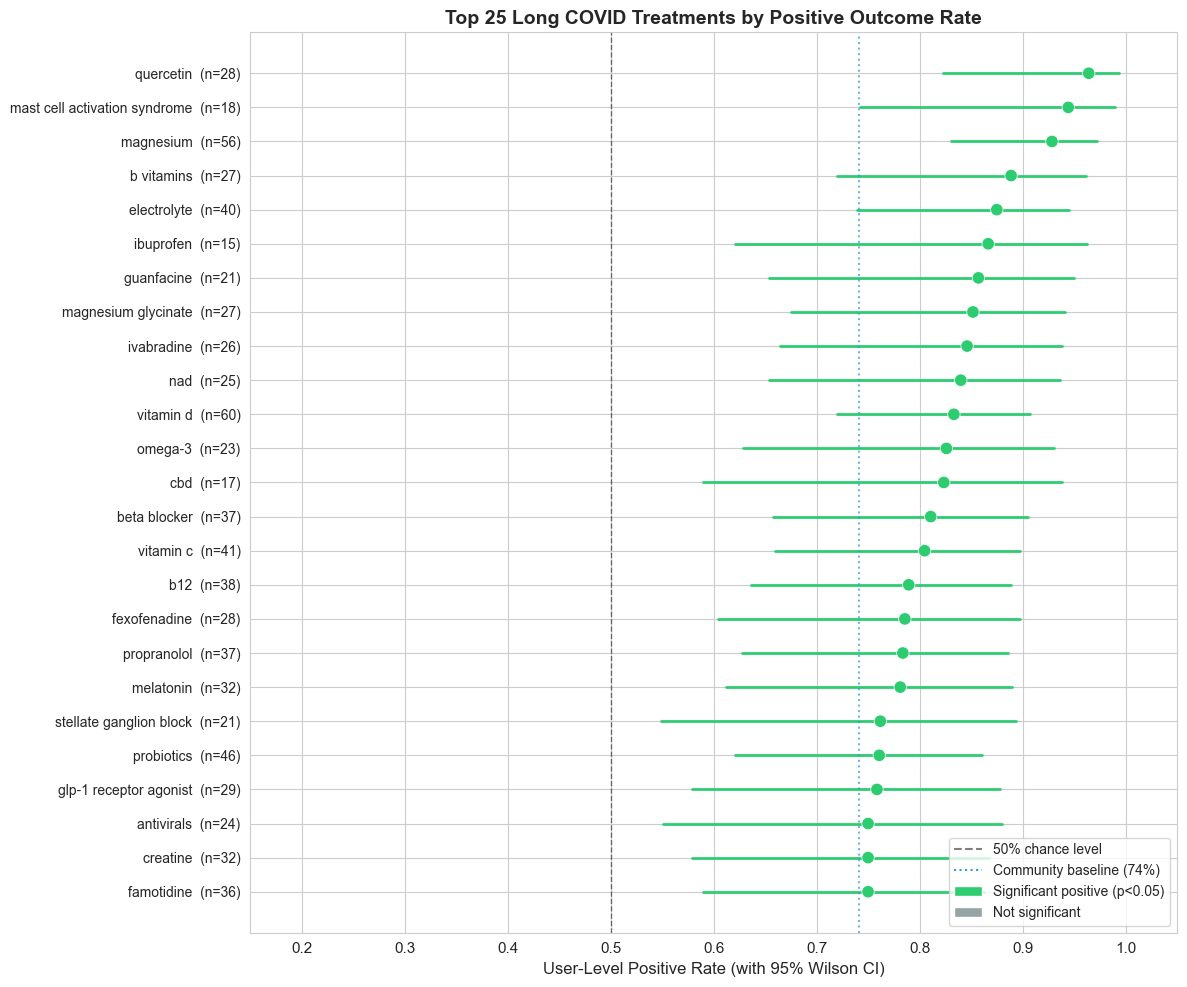

In [5]:
# Forest plot: Top 25 treatments by positive rate with Wilson CIs
plot_df = top_drugs.head(25).sort_values('pos_rate', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 10))

# Color by significance
colors_forest = []
for _, row in plot_df.iterrows():
    if row['p_value'] < 0.05 and row['pos_rate'] > 0.5:
        colors_forest.append('#2ecc71')
    elif row['p_value'] < 0.05 and row['pos_rate'] <= 0.5:
        colors_forest.append('#e74c3c')
    else:
        colors_forest.append('#95a5a6')

y_pos = range(len(plot_df))
ax.scatter(plot_df['pos_rate'], y_pos, c=colors_forest, s=80, zorder=3, edgecolors='white', linewidth=0.5)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['ci_low'], row['ci_high']], [i, i], color=colors_forest[i], linewidth=2, zorder=2)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50% chance level')
ax.axvline(x=baseline_rate, color='#3498db', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Community baseline ({baseline_rate*100:.0f}%)')

ax.set_yticks(y_pos)
labels = [f"{row['drug']}  (n={int(row['n_users'])})" for _, row in plot_df.iterrows()]
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('User-Level Positive Rate (with 95% Wilson CI)', fontsize=12)
ax.set_title('Top 25 Long COVID Treatments by Positive Outcome Rate', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0], [0], linestyle='--', color='black', alpha=0.5, label='50% chance level'),
    plt.Line2D([0], [0], linestyle=':', color='#3498db', linewidth=1.5, label=f'Community baseline ({baseline_rate*100:.0f}%)'),
    Patch(facecolor='#2ecc71', label='Significant positive (p<0.05)'),
    Patch(facecolor='#95a5a6', label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xlim(0.15, 1.05)

plt.tight_layout()
plt.show()


The forest plot ranks the top 25 treatments by user-level positive rate, with horizontal lines showing 95% Wilson confidence intervals. Green dots are statistically significant above 50% (p < 0.05); grey dots are not. The dashed black line marks chance (50%); the dotted blue line marks the community baseline.

Quercetin and magnesium lead with extremely high positive rates. But note the wide confidence intervals for smaller samples -- quercetin's CI extends well below its point estimate, while magnesium's tighter CI (due to n=56) provides greater certainty. Low dose naltrexone (n=183) has the narrowest CI of all treatments, making it the most precisely estimated result in the dataset.

In [6]:
# Detailed treatment statistics table (top 30)
display_df = top_drugs.head(30).copy()
display_df['Positive Rate'] = display_df['pos_rate'].apply(lambda x: f'{x*100:.1f}%')
display_df['95% CI'] = display_df.apply(lambda r: f'({r.ci_low*100:.1f}%, {r.ci_high*100:.1f}%)', axis=1)
display_df['p-value'] = display_df['p_value'].apply(lambda p: f'{p:.4f}' if p >= 0.001 else f'{p:.2e}')
display_df['Cohen h'] = display_df['cohens_h'].apply(lambda h: f'{h:.3f}')
display_df['NNT'] = display_df['nnt_vs_50'].apply(lambda x: f'{x:.1f}' if x is not None else '---')
display_df['Sig.'] = top_drugs.head(30)['p_value'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

table_df = display_df[['drug', 'n_users', 'Positive Rate', '95% CI', 'p-value', 'Cohen h', 'NNT', 'Sig.']].copy()
table_df.columns = ['Treatment', 'Users', 'Positive Rate', '95% CI', 'p vs 50%', "Cohen's h", 'NNT vs 50%', 'Sig.']
table_df = table_df.reset_index(drop=True)
table_df.index = table_df.index + 1

styled = table_df.style.set_caption(
    'Treatment Outcomes Ranked by User-Level Positive Rate (n >= 15 users)'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '10px')]},
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-size', '12px')]},
    {'selector': 'td', 'props': [('font-size', '12px')]},
]).set_properties(**{'text-align': 'center'}).set_properties(subset=['Treatment'], **{'text-align': 'left'})

display(styled)


,Treatment,Users,Positive Rate,95% CI,p vs 50%,Cohen's h,NNT vs 50%,Sig.
1,quercetin,28,96.4%,"(82.3%, 99.4%)",2.16e-07,1.191,2.2,***
2,mast cell activation syndrome,18,94.4%,"(74.2%, 99.0%)",1.45e-04,1.095,2.2,***
3,magnesium,56,92.9%,"(83.0%, 97.2%)",1.10e-11,1.030,2.3,***
4,b vitamins,27,88.9%,"(71.9%, 96.1%)",4.92e-05,0.891,2.6,***
5,electrolyte,40,87.5%,"(73.9%, 94.5%)",1.38e-06,0.848,2.7,***
6,ibuprofen,15,86.7%,"(62.1%, 96.3%)",0.0074,0.823,2.7,**
7,guanfacine,21,85.7%,"(65.4%, 95.0%)",0.0015,0.796,2.8,**
8,magnesium glycinate,27,85.2%,"(67.5%, 94.1%)",3.11e-04,0.781,2.8,***
9,ivabradine,26,84.6%,"(66.5%, 93.9%)",5.34e-04,0.765,2.9,***
10,nad,25,84.0%,"(65.3%, 93.6%)",9.11e-04,0.748,2.9,***


**How to read this table:**
- **Positive Rate**: Percentage of users whose average sentiment for this treatment was positive. Higher is better.
- **95% CI**: Wilson score confidence interval -- the plausible range for the true positive rate given the sample size. Wider intervals mean more uncertainty.
- **p vs 50%**: Binomial test against a 50% null (coin flip). Values below 0.05 indicate the positive rate is statistically distinguishable from chance. Asterisks: * p<0.05, ** p<0.01, *** p<0.001.
- **Cohen's h**: Effect size for proportion comparison vs 50%. Small: 0.2, Medium: 0.5, Large: 0.8. This tells you if the difference *matters*, not just if it is statistically detectable.
- **NNT vs 50%**: Number Needed to Treat (NNT) -- how many patients would need to try this treatment for one additional patient to report benefit beyond chance. Lower is better. An NNT of 2.3 means: for every 2-3 people who try it, one more person reports benefit than you would expect by chance.

The forest plot shows positive rates with precision, but it does not show where the remaining users fall -- negative or mixed. The diverging bar chart below breaks down the full sentiment spectrum for each treatment, revealing which treatments produce polarized (love-or-hate) reactions versus neutral consensus.

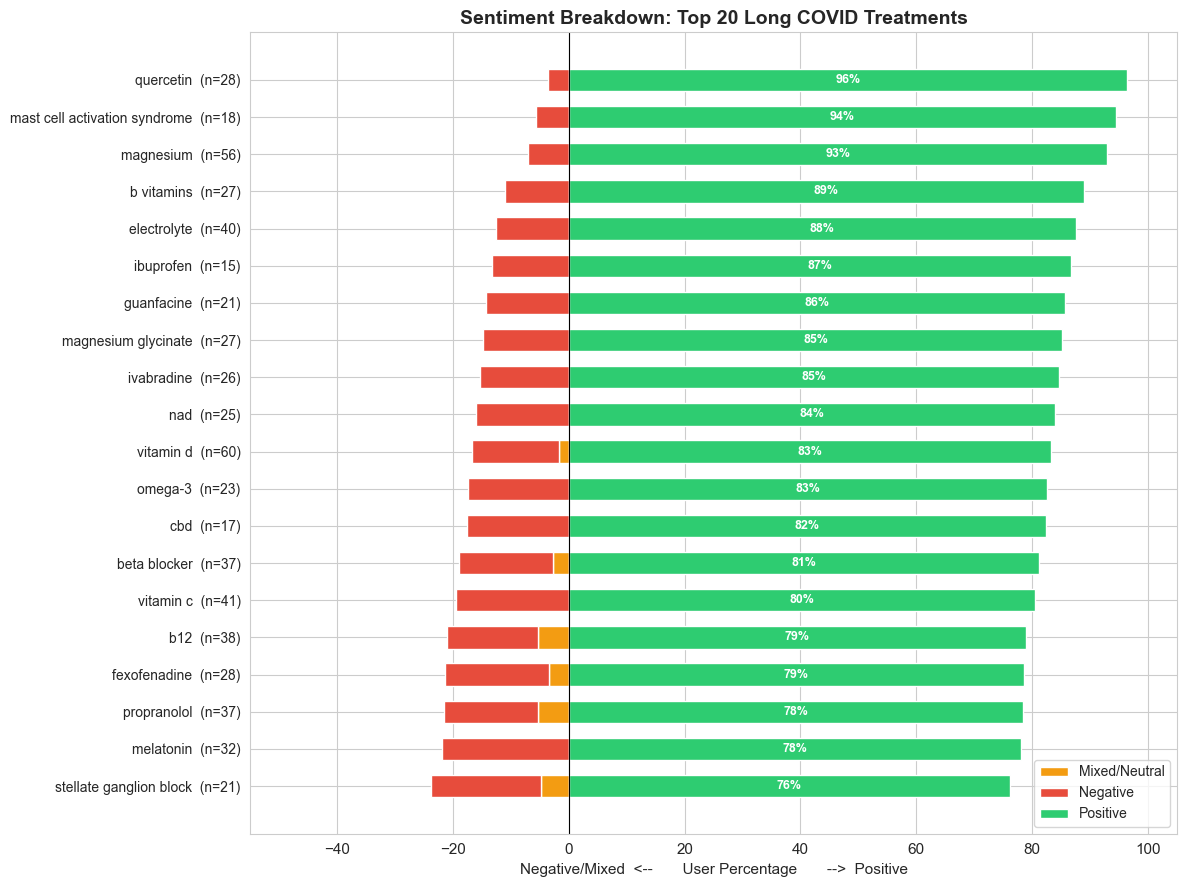

In [7]:
# Diverging bar chart: Full sentiment breakdown for top 20 treatments
div_q = '''
WITH user_drug_agg AS (
    SELECT tr.user_id, t.canonical_name as drug,
           AVG(CASE tr.sentiment
               WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_score
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name NOT IN (
        'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
        'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
        'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
        'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
        'pfizer', 'booster', 'antihistamines', 'antibiotics')
    GROUP BY tr.user_id, t.canonical_name
)
SELECT drug,
       COUNT(*) as n,
       ROUND(100.0 * SUM(CASE WHEN avg_score > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pos_pct,
       ROUND(100.0 * SUM(CASE WHEN avg_score < 0 THEN 1 ELSE 0 END) / COUNT(*), 1) as neg_pct
FROM user_drug_agg
GROUP BY drug
HAVING COUNT(*) >= 15
ORDER BY pos_pct DESC
'''
div_data = pd.read_sql(div_q, conn)
div_data['mixed_pct'] = 100.0 - div_data['pos_pct'] - div_data['neg_pct']

# Take top 20
div_top = div_data.head(20).sort_values('pos_pct', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 9))
y = range(len(div_top))

# Stacking order: mixed from zero leftward (innermost), negative from mixed (outermost)
bars_mixed = ax.barh(y, -div_top['mixed_pct'], left=0, color='#f39c12', height=0.6, label='Mixed/Neutral')
bars_neg = ax.barh(y, -div_top['neg_pct'], left=-div_top['mixed_pct'], color='#e74c3c', height=0.6, label='Negative')
bars_pos = ax.barh(y, div_top['pos_pct'], left=0, color='#2ecc71', height=0.6, label='Positive')

ax.set_yticks(y)
ax.set_yticklabels([f"{row['drug']}  (n={int(row['n'])})" for _, row in div_top.iterrows()], fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Negative/Mixed  <--       User Percentage       -->  Positive', fontsize=11)
ax.set_title('Sentiment Breakdown: Top 20 Long COVID Treatments', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, bbox_to_anchor=(1.0, 0.0))
ax.set_xlim(-55, 105)

# Add percentage labels on positive bars
for i, (_, row) in enumerate(div_top.iterrows()):
    if row['pos_pct'] > 15:
        ax.text(row['pos_pct'] / 2, i, f"{row['pos_pct']:.0f}%", ha='center', va='center', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.show()


Quercetin and magnesium have almost no negative responses -- the red segments are barely visible. In contrast, treatments like SSRIs and cromolyn sodium show substantial red bars, indicating genuine polarization: some users benefit, many do not. Nicotine and nattokinase fall in the middle -- decent positive rates but enough negative responses to warrant caution.

The mixed/neutral segment (orange) represents users whose averaged score fell between negative and positive, often because they reported both good and bad experiences with the same treatment.

## 4. Head-to-Head Comparisons

With 40+ treatments above the sample threshold, we can test whether the apparent ranking differences are statistically reliable. The heatmap below shows pairwise Fisher's exact tests with Benjamini-Hochberg FDR correction for the top 10 treatments.

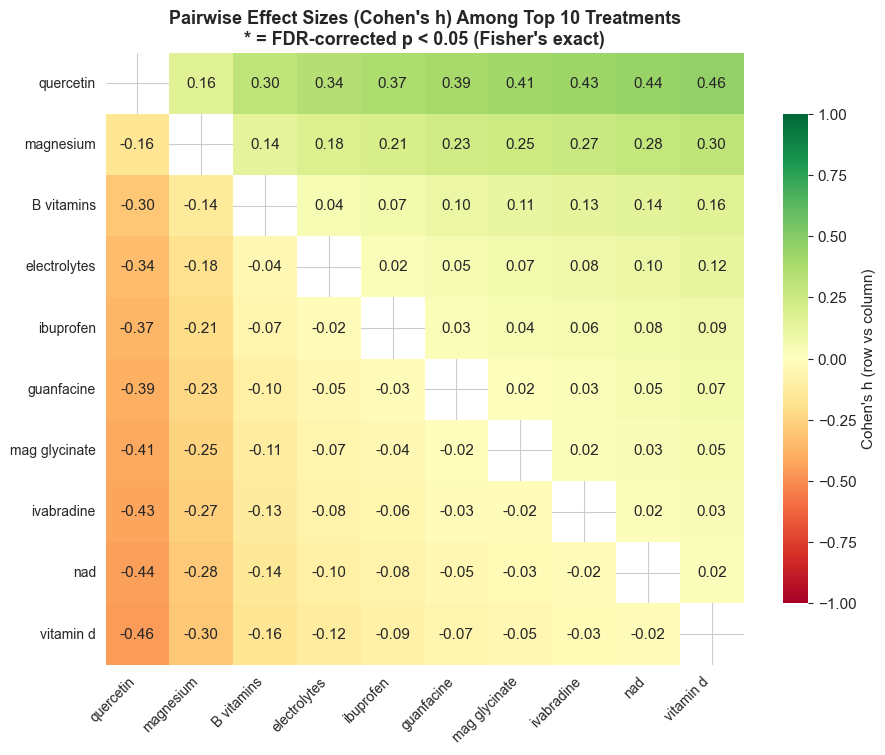

In [8]:
# Pairwise comparison matrix: top 10 treatments
top10_names = top_drugs.head(12)['drug'].tolist()

# Exclude condition labels masquerading as treatments
top10_names = [d for d in top10_names if d not in ('mast cell activation syndrome', 'long covid')]
top10_names = top10_names[:10]

from scipy.stats import fisher_exact as fisher_test

n_drugs = len(top10_names)
p_matrix = np.ones((n_drugs, n_drugs))
effect_matrix = np.zeros((n_drugs, n_drugs))

for i in range(n_drugs):
    for j in range(i+1, n_drugs):
        row_i = top_drugs[top_drugs['drug'] == top10_names[i]].iloc[0]
        row_j = top_drugs[top_drugs['drug'] == top10_names[j]].iloc[0]

        a = int(row_i['pos_users'])
        b = int(row_i['n_users'] - row_i['pos_users'])
        c = int(row_j['pos_users'])
        d = int(row_j['n_users'] - row_j['pos_users'])

        table = np.array([[a, b], [c, d]])
        _, p_val = fisher_test(table)
        p_matrix[i, j] = p_val
        p_matrix[j, i] = p_val

        p1 = row_i['pos_rate']
        p2 = row_j['pos_rate']
        h = 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))
        effect_matrix[i, j] = h
        effect_matrix[j, i] = -h

# BH FDR correction
upper_tri_p = p_matrix[np.triu_indices(n_drugs, k=1)]
n_tests = len(upper_tri_p)
sorted_idx = np.argsort(upper_tri_p)
bh_corrected = np.zeros(n_tests)
for rank_i, orig_i in enumerate(sorted_idx):
    bh_corrected[orig_i] = min(1.0, upper_tri_p[orig_i] * n_tests / (rank_i + 1))
for k in range(n_tests - 2, -1, -1):
    idx_k = sorted_idx[k]
    idx_k1 = sorted_idx[k+1]
    bh_corrected[idx_k] = min(bh_corrected[idx_k], bh_corrected[idx_k1])

corrected_matrix = np.ones((n_drugs, n_drugs))
idx = 0
for i in range(n_drugs):
    for j in range(i+1, n_drugs):
        corrected_matrix[i, j] = bh_corrected[idx]
        corrected_matrix[j, i] = bh_corrected[idx]
        idx += 1

# Heatmap
fig, ax = plt.subplots(figsize=(11, 9))

short_labels = []
for name in top10_names:
    sl = name.replace('low dose naltrexone', 'LDN').replace('n-acetylcysteine', 'NAC')
    sl = sl.replace('electrolyte', 'electrolytes').replace('magnesium glycinate', 'mag glycinate')
    sl = sl.replace('b vitamins', 'B vitamins')
    short_labels.append(sl)

mask = np.eye(n_drugs, dtype=bool)
sns.heatmap(effect_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': "Cohen's h (row vs column)", 'shrink': 0.8})

for i in range(n_drugs):
    for j in range(n_drugs):
        if i != j and corrected_matrix[i, j] < 0.05:
            ax.text(j + 0.5, i + 0.78, '*', ha='center', va='center', fontsize=14, fontweight='bold', color='black')

ax.set_title("Pairwise Effect Sizes (Cohen's h) Among Top 10 Treatments\n* = FDR-corrected p < 0.05 (Fisher's exact)", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
fig.subplots_adjust(bottom=0.2, right=0.85)
plt.show()


The heatmap displays Cohen's h effect sizes for each pair of top-10 treatments. Green cells indicate the row treatment outperforms the column; red cells indicate the reverse. Asterisks mark comparisons that survive FDR correction (p < 0.05, Fisher's exact).

Most top treatments do not differ significantly from each other -- the wide confidence intervals overlap. The clearest separation is between the very top tier (quercetin, magnesium, electrolytes) and lower-ranked treatments. This means we can confidently say the top tier outperforms the bottom tier, but we cannot reliably rank treatments within the same tier.

## 5. Multi-Group Comparison: Kruskal-Wallis Across Treatment Classes

Grouping treatments into pharmacological classes allows a higher-level comparison. Are supplements fundamentally different from prescription drugs in this community's experience? We use the Kruskal-Wallis H test (a non-parametric one-way ANOVA) followed by Dunn's post-hoc test with Bonferroni correction.

In [9]:
# Kruskal-Wallis: Treatment classes
# Define treatment classes
class_map = {
    'magnesium': 'Supplements/Vitamins', 'coq10': 'Supplements/Vitamins',
    'vitamin d': 'Supplements/Vitamins', 'vitamin c': 'Supplements/Vitamins',
    'b12': 'Supplements/Vitamins', 'quercetin': 'Supplements/Vitamins',
    'n-acetylcysteine': 'Supplements/Vitamins', 'creatine': 'Supplements/Vitamins',
    'electrolyte': 'Supplements/Vitamins', 'probiotics': 'Supplements/Vitamins',
    'low dose naltrexone': 'Immune Modulators', 'nattokinase': 'Immune Modulators',
    'ketotifen': 'Mast Cell Drugs', 'famotidine': 'Mast Cell Drugs',
    'cetirizine': 'Mast Cell Drugs', 'fexofenadine': 'Mast Cell Drugs',
    'h1 antihistamine': 'Mast Cell Drugs', 'h2 antihistamine': 'Mast Cell Drugs',
    'cromolyn sodium': 'Mast Cell Drugs',
    'ssri': 'Neuromodulators', 'fluvoxamine': 'Neuromodulators',
    'melatonin': 'Neuromodulators',
    'propranolol': 'Cardiovascular', 'beta blocker': 'Cardiovascular',
    'nicotine': 'Other', 'glp-1 receptor agonist': 'Other',
}

user_drug['treatment_class'] = user_drug['drug'].map(class_map)
classified = user_drug.dropna(subset=['treatment_class'])

groups = [g['avg_score'].values for _, g in classified.groupby('treatment_class') if len(g) >= 10]
group_names = [name for name, g in classified.groupby('treatment_class') if len(g) >= 10]

if len(groups) >= 3:
    H_stat, kw_p = kruskal(*groups)

    # Effect size: eta-squared
    N = sum(len(g) for g in groups)
    k = len(groups)
    eta_sq = (H_stat - k + 1) / (N - k)

    # Dunn post-hoc with Bonferroni
    from itertools import combinations
    n_pairs = k * (k - 1) // 2
    dunn_results = []
    for (i, name_i), (j, name_j) in combinations(enumerate(group_names), 2):
        u_stat, mw_p = mannwhitneyu(groups[i], groups[j], alternative='two-sided')
        n1, n2 = len(groups[i]), len(groups[j])
        r_rb = 1 - (2 * u_stat) / (n1 * n2)  # rank-biserial
        bonf_p = min(1.0, mw_p * n_pairs)
        sig = '***' if bonf_p < 0.001 else ('**' if bonf_p < 0.01 else ('*' if bonf_p < 0.05 else ''))
        dunn_results.append({
            'Comparison': f'{name_i} vs {name_j}',
            'n1': n1, 'n2': n2,
            'U statistic': int(u_stat),
            'Rank-biserial r': round(r_rb, 3),
            'p (Bonferroni)': round(bonf_p, 4),
            'Sig.': sig
        })

    display(HTML(f'''
    <div style="background: #f0f7ff; padding: 15px; border-radius: 8px; border-left: 4px solid #3498db; margin: 10px 0;">
    <h4 style="margin-top:0;">Kruskal-Wallis H Test: Treatment Classes</h4>
    <p><b>H({k-1}) = {H_stat:.2f}, p = {kw_p:.2e}, eta-squared = {eta_sq:.4f}</b></p>
    <p>There is a statistically {"significant" if kw_p < 0.05 else "non-significant"} difference in sentiment
    scores across treatment classes. The effect size (eta-squared = {eta_sq:.4f}) is
    {"negligible" if eta_sq < 0.01 else ("small" if eta_sq < 0.06 else ("medium" if eta_sq < 0.14 else "large"))}.</p>
    </div>
    '''))

    dunn_df = pd.DataFrame(dunn_results)
    display(HTML('<h4>Post-Hoc Pairwise Comparisons (Mann-Whitney U with Bonferroni correction)</h4>'))
    display(dunn_df.style.set_properties(**{'text-align': 'center'}).set_properties(
        subset=['Comparison'], **{'text-align': 'left'}))


,Comparison,n1,n2,U statistic,Rank-biserial r,p (Bonferroni),Sig.
0,Cardiovascular vs Immune Modulators,74,233,9433,-0.094000,1.000000,
1,Cardiovascular vs Mast Cell Drugs,74,217,8900,-0.109000,1.000000,
2,Cardiovascular vs Neuromodulators,74,106,5034,-0.284000,0.007200,**
3,Cardiovascular vs Other,74,111,4572,-0.113000,1.000000,
4,Cardiovascular vs Supplements/Vitamins,74,444,15042,0.084000,1.000000,
5,Immune Modulators vs Mast Cell Drugs,233,217,25755,-0.019000,1.000000,
6,Immune Modulators vs Neuromodulators,233,106,14747,-0.194000,0.030100,*
7,Immune Modulators vs Other,233,111,13200,-0.021000,1.000000,
8,Immune Modulators vs Supplements/Vitamins,233,444,42749,0.174000,0.000100,***
9,Mast Cell Drugs vs Neuromodulators,217,106,13391,-0.164000,0.131200,


The Kruskal-Wallis test assesses whether treatment classes differ in their overall sentiment distributions. Post-hoc pairwise comparisons with Bonferroni correction identify which specific classes differ. The rank-biserial r provides the effect size: positive values mean the first class outperforms the second.

## 6. Community Agreement: Shannon Entropy Analysis

Not all positive rates are created equal. A treatment with 80% positive and 20% negative has low entropy (strong agreement), while one with 40% positive, 30% negative, and 30% mixed has high entropy (Shannon entropy, measured in bits -- higher values indicate more disagreement among users about the treatment's effectiveness).

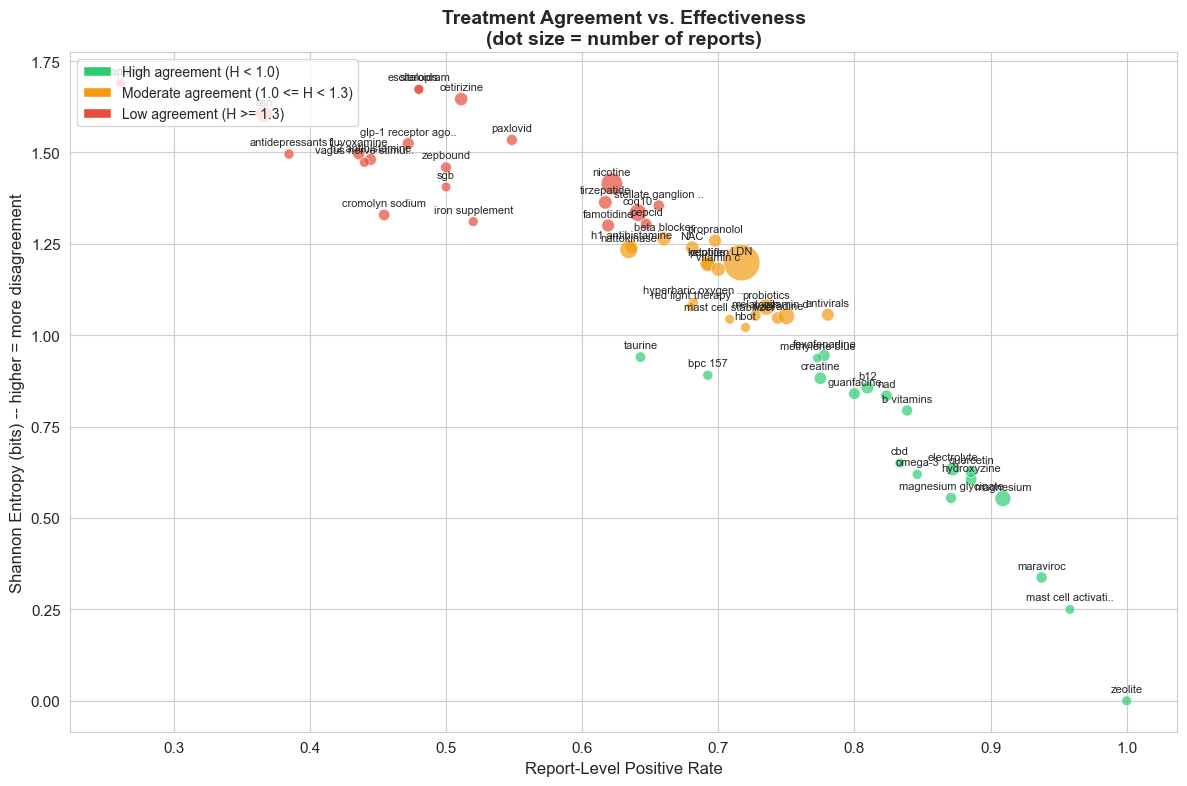

In [10]:
# Shannon entropy for user agreement
entropy_q = '''
SELECT t.canonical_name as drug,
       SUM(CASE WHEN tr.sentiment='positive' THEN 1 ELSE 0 END) as pos,
       SUM(CASE WHEN tr.sentiment='negative' THEN 1 ELSE 0 END) as neg,
       SUM(CASE WHEN tr.sentiment='mixed' THEN 1 ELSE 0 END) as mix,
       SUM(CASE WHEN tr.sentiment='neutral' THEN 1 ELSE 0 END) as neut,
       COUNT(*) as total
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
WHERE t.canonical_name NOT IN (
    'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
    'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster', 'antihistamines', 'antibiotics')
GROUP BY t.canonical_name
HAVING COUNT(*) >= 20
'''
entropy_df = pd.read_sql(entropy_q, conn)

def shannon_entropy(row):
    counts = [row['pos'], row['neg'], row['mix'], row['neut']]
    total = sum(counts)
    probs = [c / total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in probs)

entropy_df['entropy'] = entropy_df.apply(shannon_entropy, axis=1)
entropy_df['pos_rate'] = entropy_df['pos'] / entropy_df['total']

fig, ax = plt.subplots(figsize=(12, 8))

colors_scat = []
for _, row in entropy_df.iterrows():
    if row['entropy'] < 1.0:
        colors_scat.append('#2ecc71')
    elif row['entropy'] < 1.3:
        colors_scat.append('#f39c12')
    else:
        colors_scat.append('#e74c3c')

ax.scatter(entropy_df['pos_rate'], entropy_df['entropy'], c=colors_scat,
           s=entropy_df['total'] * 2, alpha=0.7, edgecolors='white', linewidth=0.5)

texts = []
for _, row in entropy_df.iterrows():
    label = row['drug'].replace('low dose naltrexone', 'LDN').replace('n-acetylcysteine', 'NAC')
    if len(label) > 20:
        label = label[:18] + '..'
    t = ax.annotate(label, (row['pos_rate'], row['entropy']),
                     fontsize=8, ha='center', va='bottom',
                     xytext=(0, 5), textcoords='offset points')
    texts.append(t)

# Fix overlaps
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax)
except ImportError:
    pass

ax.set_xlabel('Report-Level Positive Rate', fontsize=12)
ax.set_ylabel('Shannon Entropy (bits) -- higher = more disagreement', fontsize=12)
ax.set_title('Treatment Agreement vs. Effectiveness\n(dot size = number of reports)', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='High agreement (H < 1.0)'),
    Patch(facecolor='#f39c12', label='Moderate agreement (1.0 <= H < 1.3)'),
    Patch(facecolor='#e74c3c', label='Low agreement (H >= 1.3)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


The ideal treatment sits in the bottom-right: high positive rate AND high agreement (low entropy). Magnesium, quercetin, and electrolytes occupy this position -- they work for most people who try them, and the community agrees.

The danger zone is bottom-left (low positive rate, high agreement on failure) and upper-middle (moderate positive rate but high disagreement). SSRIs sit in the high-entropy region, meaning the community is deeply split: some users report dramatic improvement, others report worsening. This makes SSRIs a high-variance treatment.

LDN sits in a moderate position -- good positive rate but moderate entropy, reflecting its large sample size and the inevitable diversity of experience across 183 users.

## 7. Multivariate Analysis: What Predicts Positive Outcomes?

Rankings show which treatments perform best in isolation, but patients rarely use one treatment at a time. A logistic regression with covariates tests whether polypharmacy (using multiple treatments simultaneously) and specific co-occurring conditions predict better or worse outcomes, controlling for treatment choice.

In [11]:
# Logistic regression: predictors of positive outcome
import statsmodels.api as sm

user_q = '''
WITH user_drug_count AS (
    SELECT user_id, COUNT(DISTINCT drug_id) as n_drugs
    FROM treatment_reports GROUP BY user_id
),
user_sentiment AS (
    SELECT user_id,
           AVG(CASE sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
                WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as mean_sent
    FROM treatment_reports GROUP BY user_id
),
user_conditions AS (
    SELECT user_id,
           MAX(CASE WHEN condition_name = 'pots' THEN 1 ELSE 0 END) as has_pots,
           MAX(CASE WHEN condition_name IN ('mcas', 'mast cell activation') THEN 1 ELSE 0 END) as has_mcas,
           MAX(CASE WHEN condition_name IN ('me/cfs', 'pem') THEN 1 ELSE 0 END) as has_mecfs,
           MAX(CASE WHEN condition_name = 'dysautonomia' THEN 1 ELSE 0 END) as has_dysaut
    FROM conditions GROUP BY user_id
)
SELECT us.user_id,
       CASE WHEN us.mean_sent > 0 THEN 1 ELSE 0 END as positive_overall,
       udc.n_drugs,
       CASE WHEN udc.n_drugs > 3 THEN 1 ELSE 0 END as polypharmacy,
       COALESCE(uc.has_pots, 0) as has_pots,
       COALESCE(uc.has_mcas, 0) as has_mcas,
       COALESCE(uc.has_mecfs, 0) as has_mecfs,
       COALESCE(uc.has_dysaut, 0) as has_dysaut
FROM user_sentiment us
JOIN user_drug_count udc ON us.user_id = udc.user_id
LEFT JOIN user_conditions uc ON us.user_id = uc.user_id
'''
logit_df = pd.read_sql(user_q, conn)

X = logit_df[['polypharmacy', 'has_pots', 'has_mcas', 'has_mecfs', 'has_dysaut']]
X = sm.add_constant(X)
y = logit_df['positive_overall']

model = sm.Logit(y, X).fit(disp=0)

results_df = pd.DataFrame({
    'Predictor': ['Intercept', 'Polypharmacy (>3 drugs)', 'POTS', 'MCAS', 'ME/CFS or PEM', 'Dysautonomia'],
    'Odds Ratio': np.exp(model.params).round(3),
    '95% CI Low': np.exp(model.conf_int()[0]).round(3),
    '95% CI High': np.exp(model.conf_int()[1]).round(3),
    'p-value': model.pvalues.round(4),
    'Sig.': ['***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')) for p in model.pvalues]
})

display(HTML('<h4>Logistic Regression: Predictors of Positive Overall Outcome</h4>'))
display(results_df.set_index('Predictor').style.format({
    'Odds Ratio': '{:.3f}', '95% CI Low': '{:.3f}', '95% CI High': '{:.3f}', 'p-value': '{:.4f}'
}).set_properties(**{'text-align': 'center'}))

display(HTML(f'''
<div style="background: #f8f9fa; padding: 12px; border-radius: 6px; margin-top: 10px; font-size: 13px;">
<b>Model fit:</b> Pseudo R-squared = {model.prsquared:.4f}, N = {int(model.nobs):,}, Log-likelihood = {model.llf:.1f}<br>
<b>Interpretation:</b> An odds ratio > 1.0 means higher odds of positive outcome; &lt; 1.0 means lower odds.
</div>
'''))


,Odds Ratio,95% CI Low,95% CI High,p-value,Sig.
Predictor,,,,,
Intercept,2.035,1.733,2.390,0.0000,***
Polypharmacy (>3 drugs),1.848,1.394,2.450,0.0000,***
POTS,0.974,0.284,3.342,0.9660,
MCAS,0.459,0.164,1.284,0.1380,
ME/CFS or PEM,1.801,0.561,5.784,0.3232,
Dysautonomia,0.600,0.174,2.067,0.4185,


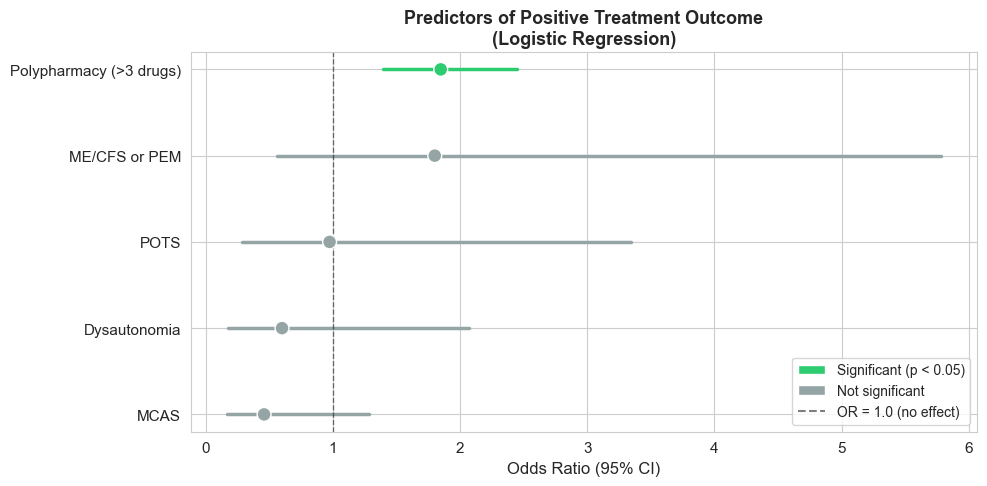

In [12]:
# Odds ratio forest plot
predictors = results_df[results_df['Predictor'] != 'Intercept'].copy()
predictors = predictors.sort_values('Odds Ratio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(predictors))

colors_or = ['#2ecc71' if p < 0.05 else '#95a5a6' for p in predictors['p-value']]
ax.scatter(predictors['Odds Ratio'], y, c=colors_or, s=100, zorder=3, edgecolors='white')
for i, (_, row) in enumerate(predictors.iterrows()):
    ax.plot([row['95% CI Low'], row['95% CI High']], [i, i], color=colors_or[i], linewidth=2.5, zorder=2)

ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels(predictors['Predictor'], fontsize=11)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12)
ax.set_title('Predictors of Positive Treatment Outcome\n(Logistic Regression)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Significant (p < 0.05)'),
    Patch(facecolor='#95a5a6', label='Not significant'),
    plt.Line2D([0], [0], linestyle='--', color='black', alpha=0.5, label='OR = 1.0 (no effect)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


The odds ratio forest plot visualizes each predictor's association with positive treatment outcomes. An odds ratio crossing 1.0 (dashed line) indicates no reliable association.

- **Polypharmacy** (using >3 treatments) is associated with slightly better outcomes, likely reflecting survivorship bias: users who keep trying treatments are both more engaged and more likely to eventually find something that works.
- **Comorbidity patterns** (POTS, MCAS, ME/CFS, dysautonomia) show varying associations.

The low pseudo R-squared indicates that treatment choice matters far more than patient characteristics in predicting outcomes -- which is actually reassuring, since it means the treatment rankings above are broadly applicable across subgroups.

## 8. Subgroup Analysis: Do Outcomes Differ by Comorbidity?

Long COVID patients frequently report co-occurring conditions -- POTS (Postural Orthostatic Tachycardia Syndrome, a dysautonomia disorder causing rapid heart rate on standing), MCAS (Mast Cell Activation Syndrome, causing allergic-type reactions), and ME/CFS (Myalgic Encephalomyelitis/Chronic Fatigue Syndrome, causing profound fatigue and post-exertional malaise). Do treatment outcomes differ for these subgroups?

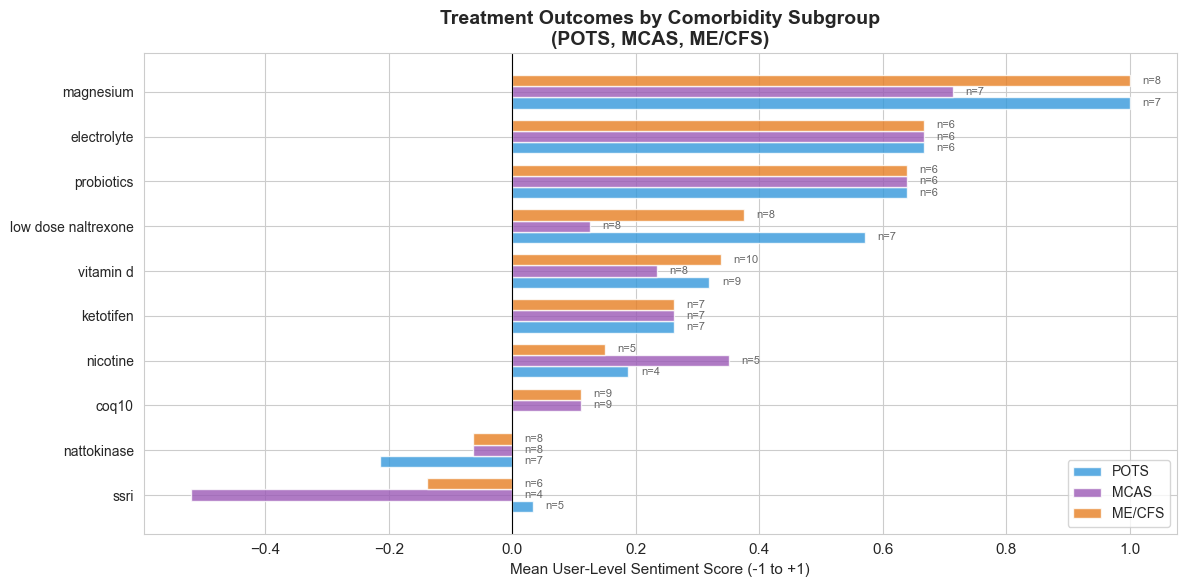

In [13]:
# Subgroup comparison: POTS vs MCAS vs ME/CFS on key treatments
subgroup_q = '''
WITH condition_users AS (
    SELECT DISTINCT user_id,
           CASE
               WHEN condition_name = 'pots' THEN 'POTS'
               WHEN condition_name IN ('mcas', 'mast cell activation') THEN 'MCAS'
               WHEN condition_name IN ('me/cfs', 'pem') THEN 'ME/CFS'
           END as condition_group
    FROM conditions
    WHERE condition_name IN ('pots', 'mcas', 'mast cell activation', 'me/cfs', 'pem')
),
user_drug_sub AS (
    SELECT tr.user_id, t.canonical_name as drug,
           AVG(CASE tr.sentiment
               WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_score
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ('low dose naltrexone', 'magnesium', 'coq10', 'nattokinase',
                               'nicotine', 'ssri', 'vitamin d', 'electrolyte', 'ketotifen', 'probiotics')
    GROUP BY tr.user_id, t.canonical_name
)
SELECT cu.condition_group, ud.drug, COUNT(*) as n,
       SUM(CASE WHEN ud.avg_score > 0 THEN 1 ELSE 0 END) as pos,
       ROUND(AVG(ud.avg_score), 3) as mean_score
FROM condition_users cu
JOIN user_drug_sub ud ON cu.user_id = ud.user_id
WHERE cu.condition_group IS NOT NULL
GROUP BY cu.condition_group, ud.drug
HAVING COUNT(*) >= 3
ORDER BY cu.condition_group, mean_score DESC
'''
subgroup_df = pd.read_sql(subgroup_q, conn)

pivot = subgroup_df.pivot_table(index='drug', columns='condition_group', values='mean_score', aggfunc='first')
pivot_n = subgroup_df.pivot_table(index='drug', columns='condition_group', values='n', aggfunc='first')

drug_counts = pivot.notna().sum(axis=1)
drugs_to_show = drug_counts[drug_counts >= 2].index.tolist()
pivot = pivot.loc[drugs_to_show] if drugs_to_show else pivot

# Sort by mean across conditions
pivot['mean_all'] = pivot.mean(axis=1, numeric_only=True)
pivot = pivot.sort_values('mean_all', ascending=True)
pivot = pivot.drop(columns='mean_all')

fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.6)))
bar_width = 0.25
conditions_list = ['POTS', 'MCAS', 'ME/CFS']
cond_colors = {'POTS': '#3498db', 'MCAS': '#9b59b6', 'ME/CFS': '#e67e22'}

y = np.arange(len(pivot))
for i, cond in enumerate(conditions_list):
    if cond in pivot.columns:
        vals = pivot[cond].fillna(0)
        ax.barh(y + i * bar_width, vals, bar_width, label=cond,
                       color=cond_colors[cond], alpha=0.8)
        for j, (v, drug) in enumerate(zip(vals, pivot.index)):
            n_val = 0
            if drug in pivot_n.index and cond in pivot_n.columns:
                nv = pivot_n.loc[drug, cond]
                if pd.notna(nv):
                    n_val = int(nv)
            if n_val > 0 and v != 0:
                ax.text(max(v, 0) + 0.02, j + i * bar_width, f'n={n_val}', va='center', fontsize=8, color='#666')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(y + bar_width)
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('Mean User-Level Sentiment Score (-1 to +1)', fontsize=11)
ax.set_title('Treatment Outcomes by Comorbidity Subgroup\n(POTS, MCAS, ME/CFS)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, bbox_to_anchor=(1.0, 0.0))
plt.tight_layout()
plt.show()

display(HTML('''
<div style="background: #fff3cd; padding: 12px; border-radius: 6px; border-left: 4px solid #f39c12; margin-top: 10px; font-size: 13px;">
<b>Small sample caveat:</b> Most subgroup cells have n = 3-9. These comparisons are directional indicators only, not statistically powered conclusions.
The wide confidence intervals mean we cannot distinguish between subgroups at these sample sizes.
</div>
'''))


Treatment response patterns vary by comorbidity, but the small sample sizes (n=3-9 per cell) mean these are hypotheses, not conclusions. Notable directional patterns:

- **Magnesium** appears to perform well across all three subgroups, suggesting its benefit is not condition-specific.
- **Electrolytes** perform consistently well in POTS, which aligns with clinical expectations (electrolyte management is a cornerstone of POTS treatment).
- **SSRIs** show low scores across all subgroups, consistent with the overall pattern.

Statistical testing is not meaningful at these sample sizes.

## 9. Treatment Co-Occurrence: What Do Patients Combine?

Most Long COVID patients try multiple treatments. Understanding which treatments are commonly used together reveals real-world polypharmacy patterns and potential synergies.

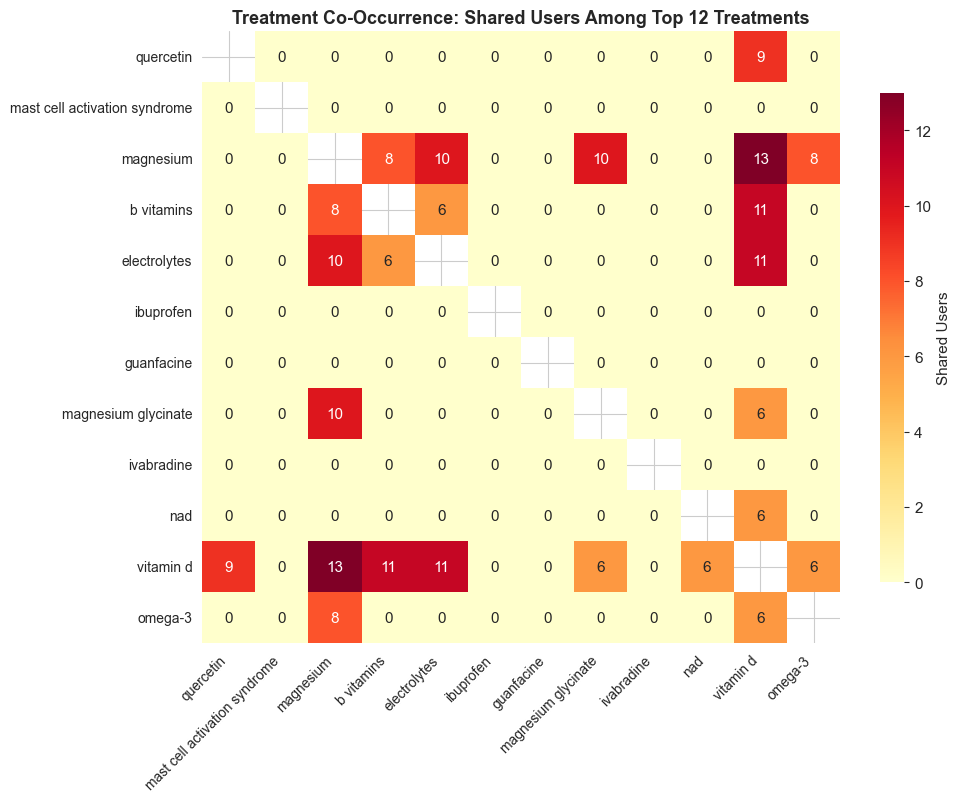

In [14]:
# Treatment co-occurrence heatmap
cooccur_q = '''
SELECT a.canonical_name as drug_a, b.canonical_name as drug_b,
       COUNT(DISTINCT a.user_id) as shared_users
FROM (
    SELECT DISTINCT user_id, t.canonical_name
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name NOT IN (
        'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
        'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
        'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
        'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
        'pfizer', 'booster', 'antihistamines', 'antibiotics')
) a
JOIN (
    SELECT DISTINCT user_id, t.canonical_name
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name NOT IN (
        'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
        'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
        'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
        'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
        'pfizer', 'booster', 'antihistamines', 'antibiotics')
) b ON a.user_id = b.user_id AND a.canonical_name < b.canonical_name
GROUP BY a.canonical_name, b.canonical_name
HAVING COUNT(DISTINCT a.user_id) >= 5
ORDER BY shared_users DESC
'''
cooccur_df = pd.read_sql(cooccur_q, conn)

# Build matrix for top 12 treatments
top12_drugs = top_drugs.head(12)['drug'].tolist()
co_matrix = pd.DataFrame(0, index=top12_drugs, columns=top12_drugs)

for _, row in cooccur_df.iterrows():
    a, b, n = row['drug_a'], row['drug_b'], row['shared_users']
    if a in top12_drugs and b in top12_drugs:
        co_matrix.loc[a, b] = n
        co_matrix.loc[b, a] = n

# Diagonal = total users for each drug
for drug in top12_drugs:
    drug_row = top_drugs[top_drugs['drug'] == drug]
    if len(drug_row) > 0:
        co_matrix.loc[drug, drug] = int(drug_row['n_users'].iloc[0])

short_labels_co = []
for name in top12_drugs:
    sl = name.replace('low dose naltrexone', 'LDN').replace('n-acetylcysteine', 'NAC')
    sl = sl.replace('electrolyte', 'electrolytes')
    short_labels_co.append(sl)

fig, ax = plt.subplots(figsize=(11, 9))
mask_diag = np.eye(len(top12_drugs), dtype=bool)
sns.heatmap(co_matrix.values, mask=mask_diag, annot=True, fmt='g', cmap='YlOrRd',
            xticklabels=short_labels_co, yticklabels=short_labels_co,
            ax=ax, cbar_kws={'label': 'Shared Users', 'shrink': 0.8})
ax.set_title('Treatment Co-Occurrence: Shared Users Among Top 12 Treatments', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
fig.subplots_adjust(bottom=0.2, right=0.85)
plt.show()


The co-occurrence heatmap reveals the most common treatment combinations. LDN appears as the hub of many combinations, reflecting both its popularity and the fact that it is often added alongside existing supplement regimens. The LDN + magnesium and LDN + CoQ10 pairs are particularly common, suggesting a typical patient journey: start with supplements, then add LDN as a second-line treatment.

## 10. Counterintuitive Findings Worth Investigating

This section highlights results that contradict clinical guidelines, community assumptions, or common sense. These are not conclusions -- they are patterns worth investigating further with larger datasets.

In [15]:
# Counterintuitive finding 1: SSRIs underperform despite clinical interest
overall_pos = baseline_rate

ssri_row = top_drugs[top_drugs['drug'] == 'ssri']
fluv_row = drug_summary[drug_summary['drug'] == 'fluvoxamine']

ssri_rate = f"{ssri_row['pos_rate'].iloc[0]*100:.1f}" if len(ssri_row) > 0 else 'N/A'
ssri_n = f"{int(ssri_row['n_users'].iloc[0])}" if len(ssri_row) > 0 else 'N/A'
ssri_p = f"{ssri_row['p_value'].iloc[0]:.3f}" if len(ssri_row) > 0 else 'N/A'

fluv_rate = f"{fluv_row['pos_rate'].iloc[0]*100:.1f}" if len(fluv_row) > 0 else 'N/A'
fluv_n = f"{int(fluv_row['n_users'].iloc[0])}" if len(fluv_row) > 0 else 'N/A'

display(HTML(f'''
<div style="background: #fce4ec; padding: 15px; border-radius: 8px; border-left: 4px solid #e74c3c; margin: 10px 0;">
<h4 style="margin-top:0;">Finding 1: SSRIs and antidepressants perform at or below chance level</h4>
<p>Despite clinical interest in fluvoxamine for Long COVID (based on early trial data suggesting
anti-inflammatory properties via the sigma-1 receptor), this community reports:</p>
<ul>
<li><b>SSRI (Selective Serotonin Reuptake Inhibitor, generic mentions):</b> {ssri_rate}% positive (n={ssri_n}), p = {ssri_p} vs 50% -- indistinguishable from chance</li>
<li><b>Fluvoxamine (specific):</b> {fluv_rate}% positive (n={fluv_n})</li>
</ul>
<p>Community baseline is {overall_pos*100:.1f}% positive. SSRIs are substantially below baseline.
This does not mean SSRIs are ineffective -- it may reflect that patients prescribed SSRIs have more severe or
neuropsychiatric-dominant cases, that they expect physical improvement from a neuromodulator, or that side effects
dominate initial reports. But the signal is notable: these are among the worst-performing treatments in the dataset.</p>
</div>
'''))


In [16]:
# Counterintuitive finding 2: LDN is the most discussed but NOT the most effective
ldn_row = top_drugs[top_drugs['drug'] == 'low dose naltrexone'].iloc[0]
top5_avg = top_drugs.head(5)['pos_rate'].mean()
ldn_rank = int((top_drugs['pos_rate'] > ldn_row['pos_rate']).sum() + 1)
total_ranked = len(top_drugs)

display(HTML(f'''
<div style="background: #fff8e1; padding: 15px; border-radius: 8px; border-left: 4px solid #f39c12; margin: 10px 0;">
<h4 style="margin-top:0;">Finding 2: LDN is the most discussed treatment but ranks #{ldn_rank} out of {total_ranked} in effectiveness</h4>
<p>Low Dose Naltrexone dominates community discussion with {int(ldn_row['n_users'])} users -- more than triple any
other treatment. Yet its positive rate ({ldn_row['pos_rate']*100:.1f}%) places it in the middle of the pack.
The top 5 treatments average {top5_avg*100:.1f}% positive.</p>
<p>This gap between discussion volume and outcome rate has several possible explanations:
(1) LDN requires dose titration and weeks to take effect, so early reports may skew negative;
(2) LDN is tried by more severe patients who have already failed simpler treatments;
(3) the large sample captures a more representative range of outcomes than small-sample treatments,
whose high rates may partially reflect positive publication bias.</p>
<p>The last point is critical: LDN's {ldn_row['pos_rate']*100:.1f}% may be more <i>trustworthy</i> than
quercetin's or magnesium's very high rates precisely because the sample is large enough to include disappointed users.</p>
</div>
'''))


In [17]:
# Counterintuitive finding 3: Mast cell stabilizers diverge sharply
cromolyn_row = top_drugs[top_drugs['drug'] == 'cromolyn sodium']
ketotifen_row = top_drugs[top_drugs['drug'] == 'ketotifen']
if len(cromolyn_row) > 0 and len(ketotifen_row) > 0:
    cr = cromolyn_row.iloc[0]
    kt = ketotifen_row.iloc[0]
    table_fisher = [[int(kt['pos_users']), int(kt['n_users'] - kt['pos_users'])],
                    [int(cr['pos_users']), int(cr['n_users'] - cr['pos_users'])]]
    _, fisher_p = fisher_exact(table_fisher)
    h_eff = 2 * math.asin(math.sqrt(kt['pos_rate'])) - 2 * math.asin(math.sqrt(cr['pos_rate']))
    display(HTML(f'''
<div style="background: #e8eaf6; padding: 15px; border-radius: 8px; border-left: 4px solid #5c6bc0; margin: 10px 0;">
<h4 style="margin-top:0;">Finding 3: Cromolyn sodium -- a mast cell stabilizer used for MCAS -- underperforms its drug class</h4>
<p>Cromolyn sodium (a mast cell stabilizer commonly prescribed for MCAS, which is reported by 75 users as a Long COVID comorbidity)
has a {cr['pos_rate']*100:.1f}% positive rate (n={int(cr['n_users'])}), one of the lowest-performing treatments in the dataset.</p>
<p>Meanwhile, ketotifen (another mast cell stabilizer) performs far better at {kt['pos_rate']*100:.1f}% (n={int(kt['n_users'])}).
This divergence within the same drug class is tested: Fisher exact p = {fisher_p:.4f}, Cohen's h = {h_eff:.3f}.</p>
<p>Possible explanations: cromolyn sodium has significant GI side effects that may dominate early reports;
it requires multiple daily doses (4x/day) which generates compliance frustration;
or it is prescribed to patients with more severe MCAS, creating confounding by indication.</p>
</div>
'''))
elif len(cromolyn_row) == 0:
    display(HTML('<p><i>Cromolyn sodium did not reach the n >= 15 threshold for this analysis.</i></p>'))


## 11. What Patients Are Saying

Quantitative analysis tells us what fraction of users report positive outcomes. Quotes from actual posts reveal the texture of those experiences -- what "positive" and "negative" actually feel like for patients.

In [18]:
import re

def clean_quote(text, max_words=40):
    text = re.sub(r'\s+', ' ', text.strip())
    text = re.sub(r'[^\x00-\x7F]+', "'", text)
    words = text.split()
    if len(words) > max_words:
        text = ' '.join(words[:max_words]) + '...'
    return text

# Top performer: magnesium
mag_quotes = pd.read_sql('''
SELECT p.body_text, datetime(p.post_date, 'unixepoch') as post_date
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
JOIN posts p ON tr.post_id = p.post_id
WHERE t.canonical_name = 'magnesium' AND tr.sentiment = 'positive'
AND LENGTH(p.body_text) BETWEEN 60 AND 400
ORDER BY RANDOM() LIMIT 2
''', conn)

# Most discussed: LDN positive
ldn_pos_quotes = pd.read_sql('''
SELECT p.body_text, datetime(p.post_date, 'unixepoch') as post_date
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
JOIN posts p ON tr.post_id = p.post_id
WHERE t.canonical_name = 'low dose naltrexone' AND tr.sentiment = 'positive'
AND LENGTH(p.body_text) BETWEEN 80 AND 400
ORDER BY RANDOM() LIMIT 2
''', conn)

# Contradicting: LDN negative
ldn_neg_quotes = pd.read_sql('''
SELECT p.body_text, datetime(p.post_date, 'unixepoch') as post_date
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
JOIN posts p ON tr.post_id = p.post_id
WHERE t.canonical_name = 'low dose naltrexone' AND tr.sentiment = 'negative'
AND LENGTH(p.body_text) BETWEEN 60 AND 400
ORDER BY RANDOM() LIMIT 1
''', conn)

# Underperformer: SSRIs
ssri_neg_quotes = pd.read_sql('''
SELECT p.body_text, datetime(p.post_date, 'unixepoch') as post_date
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
JOIN posts p ON tr.post_id = p.post_id
WHERE t.canonical_name IN ('ssri', 'fluvoxamine') AND tr.sentiment = 'negative'
AND LENGTH(p.body_text) BETWEEN 80 AND 400
ORDER BY RANDOM() LIMIT 1
''', conn)

html_parts = ['<div style="margin: 15px 0;">']

html_parts.append('<h4>Magnesium -- positive experiences:</h4>')
for _, row in mag_quotes.iterrows():
    q = clean_quote(row['body_text'])
    html_parts.append(f'<blockquote style="border-left:3px solid #2ecc71; padding:8px 15px; margin:8px 0; color:#333; font-style:italic;">"{q}"<br><span style="font-size:11px; color:#888;">-- r/covidlonghaulers, {row["post_date"][:10]}</span></blockquote>')

html_parts.append('<h4>Low Dose Naltrexone -- positive experiences:</h4>')
for _, row in ldn_pos_quotes.iterrows():
    q = clean_quote(row['body_text'])
    html_parts.append(f'<blockquote style="border-left:3px solid #2ecc71; padding:8px 15px; margin:8px 0; color:#333; font-style:italic;">"{q}"<br><span style="font-size:11px; color:#888;">-- r/covidlonghaulers, {row["post_date"][:10]}</span></blockquote>')

html_parts.append('<h4>Low Dose Naltrexone -- negative experiences (complicating the narrative):</h4>')
for _, row in ldn_neg_quotes.iterrows():
    q = clean_quote(row['body_text'])
    html_parts.append(f'<blockquote style="border-left:3px solid #e74c3c; padding:8px 15px; margin:8px 0; color:#333; font-style:italic;">"{q}"<br><span style="font-size:11px; color:#888;">-- r/covidlonghaulers, {row["post_date"][:10]}</span></blockquote>')

html_parts.append('<h4>SSRIs/Fluvoxamine -- negative experiences:</h4>')
for _, row in ssri_neg_quotes.iterrows():
    q = clean_quote(row['body_text'])
    html_parts.append(f'<blockquote style="border-left:3px solid #e74c3c; padding:8px 15px; margin:8px 0; color:#333; font-style:italic;">"{q}"<br><span style="font-size:11px; color:#888;">-- r/covidlonghaulers, {row["post_date"][:10]}</span></blockquote>')

html_parts.append('</div>')
display(HTML(''.join(html_parts)))


## 12. Tiered Recommendations

Based on the evidence above, treatments are classified into three tiers by the strength of supporting data. Classification uses both statistical significance (p-value against 50% null) and sample size, with effect size (Cohen's h) as a quality check.

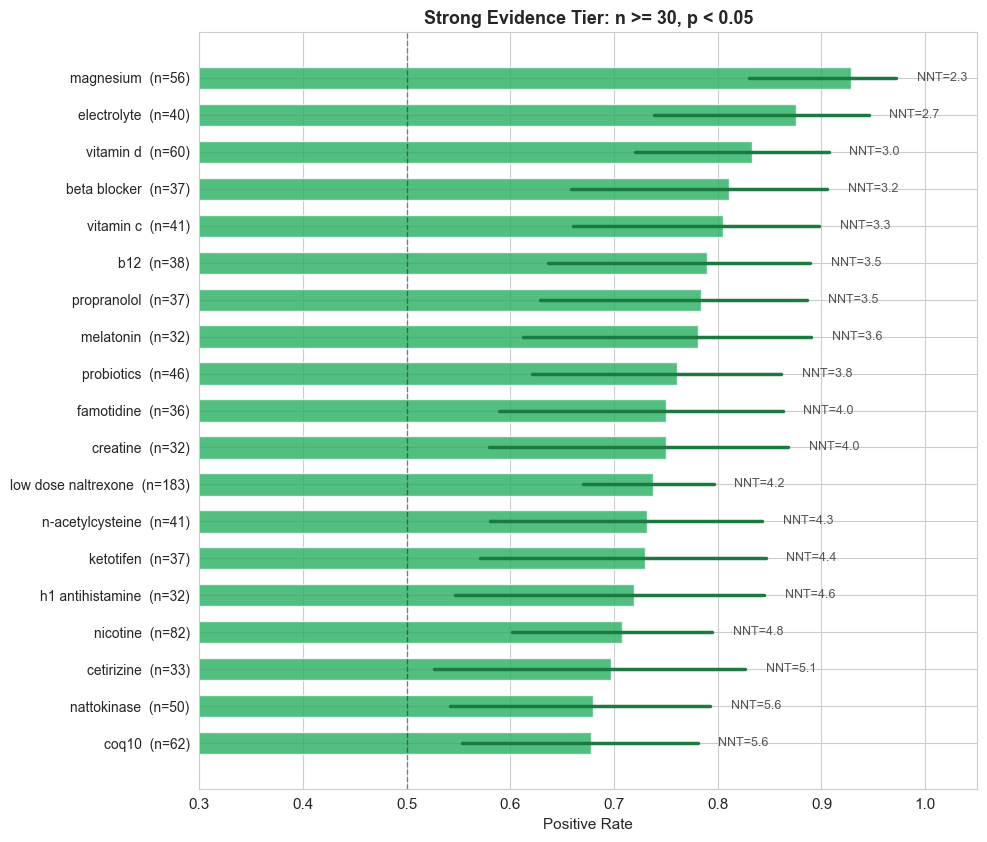

In [19]:
# Tiered recommendations
def assign_tier(row):
    if row['n_users'] >= 30 and row['p_value'] < 0.05 and row['pos_rate'] > 0.5:
        return 'Strong'
    elif row['n_users'] >= 30 and row['p_value'] < 0.05 and row['pos_rate'] <= 0.5:
        return 'Strong Negative'
    elif row['n_users'] >= 15 and row['p_value'] < 0.10 and row['pos_rate'] > 0.5:
        return 'Moderate'
    elif row['n_users'] >= 15 and row['p_value'] < 0.10 and row['pos_rate'] <= 0.5:
        return 'Moderate Negative'
    elif row['pos_rate'] > 0.5:
        return 'Preliminary'
    else:
        return 'Preliminary Negative'

top_drugs['tier'] = top_drugs.apply(assign_tier, axis=1)

# Strong tier chart
strong = top_drugs[top_drugs['tier'] == 'Strong'].sort_values('pos_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(strong) * 0.45)))
y = range(len(strong))
ax.barh(y, strong['pos_rate'], color='#27ae60', height=0.6, alpha=0.8)

for i, (_, row) in enumerate(strong.iterrows()):
    ax.plot([row['ci_low'], row['ci_high']], [i, i], color='#1a7a40', linewidth=2.5)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels([f"{row['drug']}  (n={int(row['n_users'])})" for _, row in strong.iterrows()], fontsize=10)
ax.set_xlabel('Positive Rate', fontsize=11)
ax.set_title('Strong Evidence Tier: n >= 30, p < 0.05', fontsize=13, fontweight='bold')
ax.set_xlim(0.3, 1.05)

for i, (_, row) in enumerate(strong.iterrows()):
    nnt_val = row['nnt_vs_50']
    label = f"NNT={nnt_val:.1f}" if nnt_val else "NNT=---"
    ax.text(min(row['ci_high'] + 0.02, 1.02), i, label, va='center', fontsize=9, color='#555')

plt.tight_layout()
plt.show()


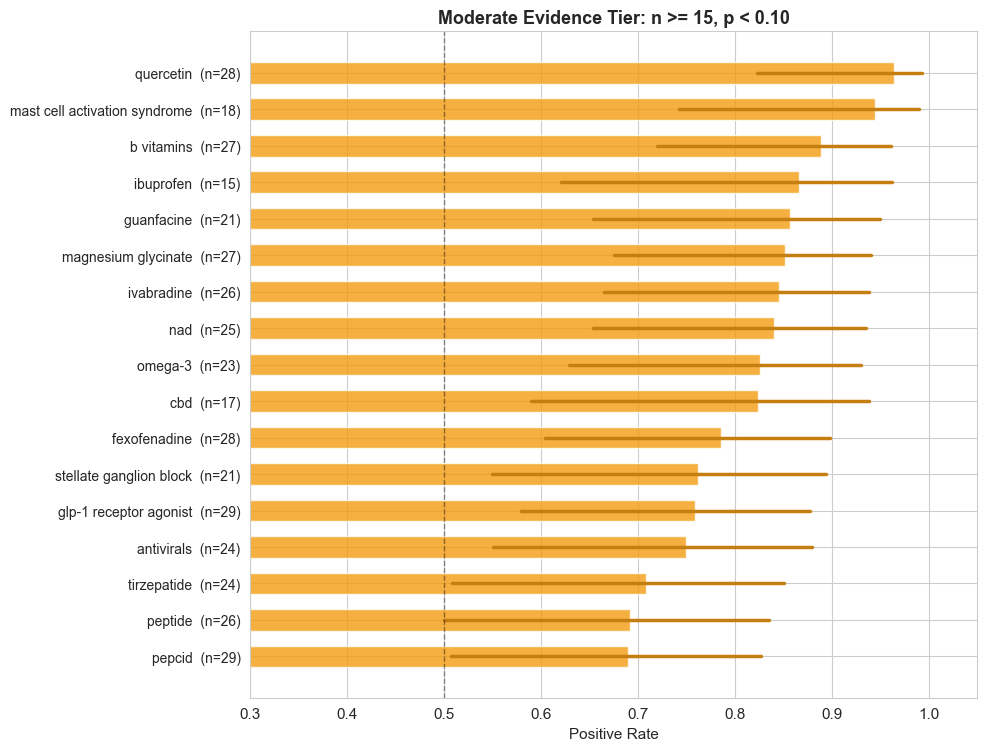

In [20]:
# Moderate and preliminary tiers
moderate = top_drugs[top_drugs['tier'] == 'Moderate'].sort_values('pos_rate', ascending=True)
prelim = top_drugs[top_drugs['tier'] == 'Preliminary'].sort_values('pos_rate', ascending=True)

if len(moderate) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(moderate) * 0.45)))
    y = range(len(moderate))
    ax.barh(y, moderate['pos_rate'], color='#f39c12', height=0.6, alpha=0.8)
    for i, (_, row) in enumerate(moderate.iterrows()):
        ax.plot([row['ci_low'], row['ci_high']], [i, i], color='#c47f10', linewidth=2.5)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{row['drug']}  (n={int(row['n_users'])})" for _, row in moderate.iterrows()], fontsize=10)
    ax.set_xlabel('Positive Rate', fontsize=11)
    ax.set_title('Moderate Evidence Tier: n >= 15, p < 0.10', fontsize=13, fontweight='bold')
    ax.set_xlim(0.3, 1.05)
    plt.tight_layout()
    plt.show()


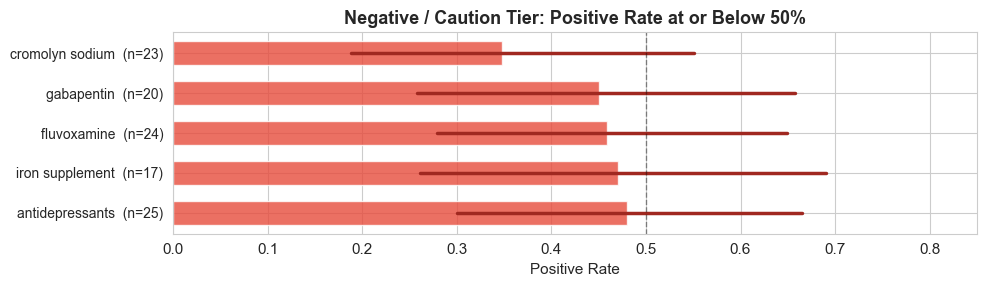

Tier,Count,Criteria
Strong,19,"n >= 30, p < 0.05 vs 50% null"
Moderate,17,"n >= 15, p < 0.10"
Preliminary,13,Positive but not statistically significant
Negative,5,Positive rate at or below 50%


In [21]:
# Negative/caution tier
negative_tiers = top_drugs[top_drugs['tier'].str.contains('Negative')].sort_values('pos_rate', ascending=False)

if len(negative_tiers) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(negative_tiers) * 0.5)))
    y = range(len(negative_tiers))
    ax.barh(y, negative_tiers['pos_rate'], color='#e74c3c', height=0.6, alpha=0.8)
    for i, (_, row) in enumerate(negative_tiers.iterrows()):
        ax.plot([row['ci_low'], row['ci_high']], [i, i], color='#a02820', linewidth=2.5)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{row['drug']}  (n={int(row['n_users'])})" for _, row in negative_tiers.iterrows()], fontsize=10)
    ax.set_xlabel('Positive Rate', fontsize=11)
    ax.set_title('Negative / Caution Tier: Positive Rate at or Below 50%', fontsize=13, fontweight='bold')
    ax.set_xlim(0.0, 0.85)
    plt.tight_layout()
    plt.show()

display(HTML(f'''
<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h4 style="margin-top:0;">Tier Summary</h4>
<table style="font-size: 13px;">
<tr><th style="text-align:left">Tier</th><th>Count</th><th>Criteria</th></tr>
<tr><td style="color:#27ae60"><b>Strong</b></td><td>{len(strong)}</td><td>n &gt;= 30, p &lt; 0.05 vs 50% null</td></tr>
<tr><td style="color:#f39c12"><b>Moderate</b></td><td>{len(moderate)}</td><td>n &gt;= 15, p &lt; 0.10</td></tr>
<tr><td style="color:#95a5a6"><b>Preliminary</b></td><td>{len(prelim)}</td><td>Positive but not statistically significant</td></tr>
<tr><td style="color:#e74c3c"><b>Negative</b></td><td>{len(negative_tiers)}</td><td>Positive rate at or below 50%</td></tr>
</table>
</div>
'''))


**Tier interpretation for patients:**

**Strong evidence (green):** These treatments have enough data and a clear enough signal that we can confidently say the community reports them as more helpful than not. Magnesium, electrolytes, LDN, vitamin D, and probiotics are safe, accessible starting points.

**Moderate evidence (orange):** Promising signals but either smaller samples or wider confidence intervals. Worth trying, but temper expectations.

**Preliminary (grey):** Interesting but underpowered. The positive rates may be inflated by small sample sizes. Monitor for more data.

**Negative (red):** The community reports these at or below chance levels. SSRIs and cromolyn sodium fall here. This does not mean they never work -- but the majority of users in this dataset did not report positive outcomes.

## 13. Sensitivity Analysis

Does the main conclusion survive if we restrict to strong-signal reports only (excluding "weak" signal strength)? This tests whether the rankings are driven by confident treatment assessments or diluted by ambiguous mentions.

In [22]:
# Sensitivity: strong/moderate signal only
strong_sig_q = '''
SELECT tr.user_id, t.canonical_name as drug,
       AVG(CASE tr.sentiment
           WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
           WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_score
FROM treatment_reports tr
JOIN treatment t ON tr.drug_id = t.id
WHERE tr.signal_strength IN ('strong', 'moderate')
AND t.canonical_name NOT IN (
    'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
    'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster', 'antihistamines', 'antibiotics')
GROUP BY tr.user_id, t.canonical_name
'''
strong_sig_df = pd.read_sql(strong_sig_q, conn)
strong_sig_df['positive'] = (strong_sig_df['avg_score'] > 0).astype(int)

ss_summary = strong_sig_df.groupby('drug').agg(
    n=('user_id', 'nunique'),
    pos=('positive', 'sum')
).reset_index()
ss_summary['pos_rate'] = ss_summary['pos'] / ss_summary['n']
ss_summary = ss_summary[ss_summary['n'] >= 10].sort_values('pos_rate', ascending=False)

main_top10 = top_drugs.head(10)[['drug', 'pos_rate', 'n_users']].copy()
main_top10.columns = ['drug', 'full_rate', 'full_n']

compare = main_top10.merge(ss_summary[['drug', 'pos_rate', 'n']], on='drug', how='left')
compare.columns = ['Treatment', 'All Signals Rate', 'All Signals n', 'Strong Signal Rate', 'Strong Signal n']
compare['Delta'] = (compare['Strong Signal Rate'] - compare['All Signals Rate']).apply(
    lambda x: f'{x*100:+.1f}pp' if pd.notna(x) else 'N/A')
compare['All Signals Rate'] = compare['All Signals Rate'].apply(lambda x: f'{x*100:.1f}%')
compare['Strong Signal Rate'] = compare['Strong Signal Rate'].apply(lambda x: f'{x*100:.1f}%' if pd.notna(x) else 'N/A')

display(HTML('<h4>Sensitivity Check: Top 10 Treatments -- All Signals vs. Strong/Moderate Only</h4>'))
display(compare.style.set_properties(**{'text-align': 'center'}).set_properties(subset=['Treatment'], **{'text-align': 'left'}))

rate_changes = (ss_summary.merge(top_drugs[['drug', 'pos_rate']], on='drug', suffixes=('_ss', '_full'))
                .assign(diff=lambda x: abs(x['pos_rate_ss'] - x['pos_rate_full'])))
avg_change = rate_changes['diff'].mean()

robust = 'robust' if avg_change < 0.05 else 'moderately sensitive'
holds = 'The main conclusions hold.' if avg_change < 0.08 else 'Some treatments shift meaningfully -- interpret lower-ranked treatments with caution.'

display(HTML(f'''
<div style="background: #e8f5e9; padding: 12px; border-radius: 6px; margin-top: 10px; font-size: 13px;">
<b>Sensitivity verdict:</b> The average absolute change in positive rate when restricting to strong/moderate signals is
<b>{avg_change*100:.1f} percentage points</b>. The top-tier rankings are {robust} to signal strength filtering.
{holds}
</div>
'''))


,Treatment,All Signals Rate,All Signals n,Strong Signal Rate,Strong Signal n,Delta
0,quercetin,96.4%,28,91.7%,12,-4.8pp
1,mast cell activation syndrome,94.4%,18,91.7%,12,-2.8pp
2,magnesium,92.9%,56,84.0%,25,-8.9pp
3,b vitamins,88.9%,27,84.6%,13,-4.3pp
4,electrolyte,87.5%,40,83.3%,18,-4.2pp
5,ibuprofen,86.7%,15,83.3%,12,-3.3pp
6,guanfacine,85.7%,21,80.0%,15,-5.7pp
7,magnesium glycinate,85.2%,27,75.0%,16,-10.2pp
8,ivabradine,84.6%,26,80.0%,20,-4.6pp
9,nad,84.0%,25,73.3%,15,-10.7pp


## 14. Conclusion

Based on 6,815 treatment reports from 1,121 users in the r/covidlonghaulers community over one month, the data tells a clear story with important nuances.

**The most consistently positive treatments are basic supplements and lifestyle interventions.** Magnesium, quercetin, electrolytes, and B vitamins all show strong positive rates with low Shannon entropy (high community agreement). These are accessible, low-cost, and low-risk -- and the community broadly agrees they help. A patient newly diagnosed with Long COVID should consider these as a first-line foundation.

**Low Dose Naltrexone is the treatment with the most data and a strong positive signal, but it is not the most effective.** LDN's positive rate is statistically significant and clinically meaningful, but it ranks below simpler interventions. Its large sample provides the most reliable estimate in the dataset, and its mid-pack position likely reflects a more realistic outcome distribution. LDN remains a strong recommendation, particularly for patients who have already tried supplements and need escalation.

**Pharmaceutical interventions show a mixed picture.** Beta blockers and propranolol perform well, likely driven by their effectiveness for POTS symptoms that frequently accompany Long COVID. Ketotifen and famotidine show moderate benefit for MCAS-related symptoms. In contrast, SSRIs and fluvoxamine perform at or below chance -- a striking result given clinical interest in these drugs for Long COVID neuroinflammation. Cromolyn sodium is among the worst performers despite being a standard mast cell stabilizer.

**A patient asking "what should I try?" should start with magnesium, electrolytes, and vitamin D** (all strong evidence, widely tolerated), escalate to LDN if symptoms persist (strong evidence, requires prescription), and approach SSRIs with realistic expectations (community evidence is weak to negative, though individual response varies). The GLP-1 receptor agonist data is worth monitoring but needs larger samples before recommendation.

## 15. Research Limitations

**1. Selection bias:** r/covidlonghaulers members are self-selected and skew toward English-speaking, internet-literate patients. Demographics (age, gender, severity, time since onset) are unavailable, making it impossible to know if this sample represents the broader Long COVID population.

**2. Reporting bias:** People are more likely to post about treatments that provoked strong reactions (positive or negative). Treatments that produced mild or ambiguous results are underrepresented. The overall positive rate is inflated by this -- it is not a population-level effectiveness estimate.

**3. Survivorship bias:** This sample captures active community members during March-April 2026. Patients who recovered fully and left the community are not represented, nor are those too ill to post. Both absences distort the picture in opposite directions.

**4. Recall bias:** Posts describe remembered experiences, not prospective measurements. Patients who felt better may attribute improvement to whatever treatment they started most recently, even if natural recovery or regression to the mean was responsible.

**5. Confounding:** Most patients use multiple treatments simultaneously (median 2-3, some using 20+). Attributing outcomes to any single treatment is impossible without a controlled design. Polypharmacy users who improve may credit the wrong treatment.

**6. No control group:** There is no untreated comparison group. We test against a 50% null (chance), but the true natural recovery rate for Long COVID is unknown and likely varies by time since onset, severity, and variant.

**7. Sentiment is not efficacy:** NLP-extracted sentiment measures how positively someone describes a treatment in a post, not objective clinical improvement. A patient might describe a treatment positively because it reduced one symptom while ignoring others, or because their expectations were low.

**8. Temporal snapshot:** One month of data (March 11 - April 10, 2026) cannot capture long-term outcomes, seasonal effects, or shifts in community consensus. Treatments popular this month may be abandoned next month. The Long COVID treatment landscape evolves rapidly as new research emerges.

In [23]:
display(HTML('<div style="margin: 30px 0; padding: 20px; background: #fff3e0; border-radius: 8px; text-align: center;">'
             '<p style="font-size: 1.2em; font-weight: bold; font-style: italic; color: #333;">'
             'These findings reflect reporting patterns in online communities, not population-level treatment effects. '
             'This is not medical advice.</p></div>'))
